## Bootstrap

C:\Users\USER\AppData\Local\Temp\ipykernel_24732\3617241097.py:26: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=START, end=END)[0].copy()
C:\Users\USER\AppData\Local\Temp\ipykernel_24732\3617241097.py:26: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=START, end=END)[0].copy()


===== Rolling MV Optimization (No forecast) =====
기간(최적화 백테스트): 2006-01-31 ~ 2025-12-31
WINDOW=60, GAMMA=5.0, LONG_ONLY=True
                           AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)        0.110580  0.155655      0.710419 -0.503117
EW Factors                  0.041258  0.081794      0.504413 -0.255091
MV-Opt (No forecast, 60M)   0.073879  0.125637      0.588039 -0.266962


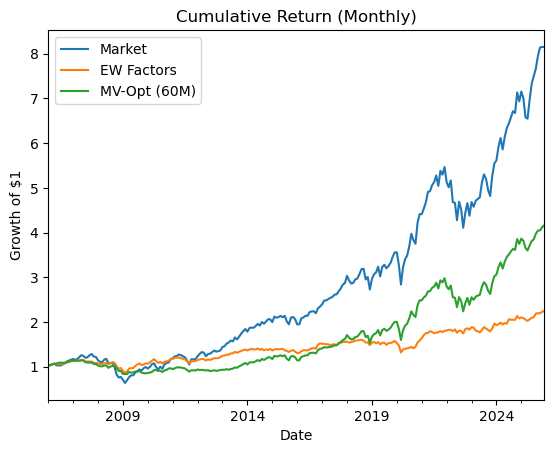

<Figure size 640x480 with 0 Axes>

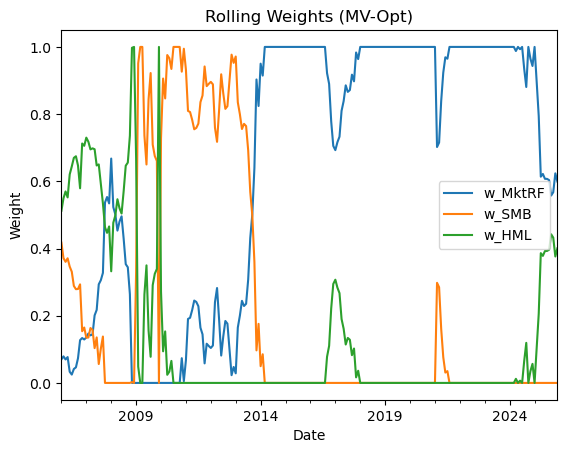


===== Rolling MV Optimization (AR1 forecast) =====
기간(최적화 백테스트): 2006-01-31 ~ 2025-12-31
WINDOW=60, GAMMA=5.0, LONG_ONLY=True
                            AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)         0.110580  0.155655      0.710419 -0.503117
EW Factors                   0.041258  0.081794      0.504413 -0.255091
MV-Opt (No forecast, 60M)    0.073879  0.125637      0.588039 -0.266962
MV-Opt (AR1 forecast, 60M)   0.086366  0.119689      0.721589 -0.206971


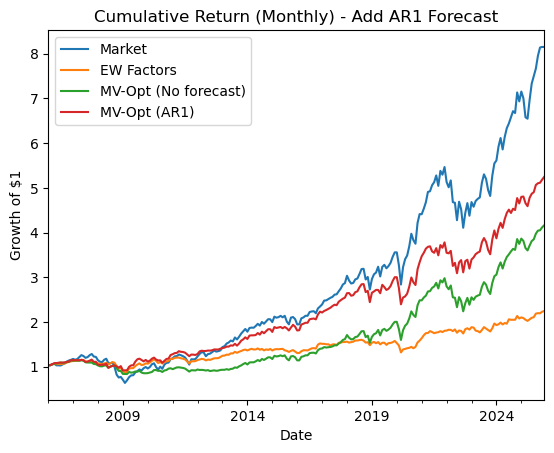

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Thu Feb 12 16:36:18 2026

@author: jx2on
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader.data as web

# =========================
# 설정
# =========================
START = "2001-01-01"
END   = "2025-12-31"

WINDOW = 60          # 60개월 rolling window
GAMMA  = 5.0         # 위험회피계수(클수록 보수적)
LONG_ONLY = True     # True면 공매도(음수 비중) 금지

# =========================
# 1) FF3 (Monthly) 불러오기
# =========================
ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=START, end=END)[0].copy()

# 인덱스를 월말 날짜로
ff.index = pd.to_datetime(ff.index.astype(str)) + pd.offsets.MonthEnd(0)

# % -> 소수
ff = ff / 100.0
ff = ff.loc[(ff.index >= START) & (ff.index <= END)].dropna()

# 사용할 팩터 (초과수익 팩터 3개)
F = ff[["Mkt-RF", "SMB", "HML"]].copy()   # excess returns
RF = ff["RF"].copy()                     # risk-free

# =========================
# 2) 벤치마크/단순전략 (비교용)
# =========================
ret_mkt = ff["Mkt-RF"] + ff["RF"]
ret_ew  = (ff["Mkt-RF"] + ff["SMB"] + ff["HML"]) / 3.0 + ff["RF"]

# =========================
# 3) 평균-분산 최적화 함수
#    w* = (1/gamma) * Sigma^{-1} * mu
#    (초과수익 기준; 총수익은 RF + w·F)
# =========================
def mv_weights(mu: np.ndarray, cov: np.ndarray, gamma: float, long_only: bool) -> np.ndarray:
    # 수치 안정화: 공분산 행렬에 작은 값 더하기
    eps = 1e-6
    cov = cov + eps * np.eye(cov.shape[0])

    w = (1.0 / gamma) * np.linalg.solve(cov, mu)  # Sigma^{-1} mu

    if long_only:
        w = np.maximum(w, 0.0)  # 음수 제거

    # 너무 크거나 이상한 값 방지: 합이 0이면 균등
    s = w.sum()
    if s <= 1e-12:
        w = np.ones_like(w) / len(w)
    else:
        # "팩터 포트폴리오"를 100%로 정규화(합=1)
        w = w / s

    return w

# =========================
# 4) Rolling backtest
# =========================
dates = F.index
rets_opt = []
w_hist = []

for t in range(WINDOW, len(dates)):
    # 추정 구간: t-WINDOW ~ t-1
    train = F.iloc[t-WINDOW:t]
    mu = train.mean().values                # (3,)
    cov = train.cov().values                # (3,3)

    w = mv_weights(mu, cov, gamma=GAMMA, long_only=LONG_ONLY)
    w_hist.append(w)

    # 투자 구간: t (다음 달) 실현 수익률
    f_next = F.iloc[t].values               # (3,)
    r_next = float(RF.iloc[t] + np.dot(w, f_next))  # 총수익 = RF + w·(excess factors)
    rets_opt.append(r_next)

ret_opt = pd.Series(rets_opt, index=dates[WINDOW:], name="MV-Opt (No forecast, 60M)")

w_hist = pd.DataFrame(w_hist, index=dates[WINDOW:], columns=["w_MktRF", "w_SMB", "w_HML"])

# =========================
# 5) 성과지표
# =========================
def perf_stats(r: pd.Series, name: str):
    r = r.dropna()
    ann_return = float((1 + r).prod() ** (12 / len(r)) - 1)
    ann_vol    = float(r.std() * np.sqrt(12))
    sharpe     = ann_return / ann_vol if ann_vol != 0 else np.nan

    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    mdd = float(dd.min())

    return pd.Series(
        {"AnnReturn": ann_return, "AnnVol": ann_vol, "Sharpe(rf=0)": sharpe, "MDD": mdd},
        name=name
    )

stats = pd.concat([
    perf_stats(ret_mkt.loc[ret_opt.index], "Market (Mkt-RF + RF)"),
    perf_stats(ret_ew.loc[ret_opt.index],  "EW Factors"),
    perf_stats(ret_opt,                   "MV-Opt (No forecast, 60M)")
], axis=1).T

print("===== Rolling MV Optimization (No forecast) =====")
print(f"기간(최적화 백테스트): {ret_opt.index[0].date()} ~ {ret_opt.index[-1].date()}")
print(f"WINDOW={WINDOW}, GAMMA={GAMMA}, LONG_ONLY={LONG_ONLY}")
print(stats)

# =========================
# 6) 그래프: 누적수익률 + 가중치 변화
# =========================
cum_mkt = (1 + ret_mkt.loc[ret_opt.index]).cumprod()
cum_ew  = (1 + ret_ew.loc[ret_opt.index]).cumprod()
cum_opt = (1 + ret_opt).cumprod()

plt.figure()
cum_mkt.plot(label="Market")
cum_ew.plot(label="EW Factors")
cum_opt.plot(label="MV-Opt (60M)")
plt.title("Cumulative Return (Monthly)")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

plt.figure()
w_hist.plot()
plt.title("Rolling Weights (MV-Opt)")
plt.ylabel("Weight")
plt.show()

from statsmodels.tsa.ar_model import AutoReg

# =========================
# AR(1)로 다음 달 팩터 프리미엄(초과수익) 예측해서 mu 만들기
# mu_hat = [E(Mkt-RF_{t+1}), E(SMB_{t+1}), E(HML_{t+1})]
# =========================
def ar1_forecast_mu(train_df: pd.DataFrame) -> np.ndarray:
    mu_hat = []
    for col in train_df.columns:
        y = train_df[col].values

        # AR(1) 적합 (상수 포함)
        model = AutoReg(y, lags=1, trend="c", old_names=False).fit()

        # 1-step ahead forecast
        f = float(model.forecast(steps=1)[0])
        mu_hat.append(f)

    return np.array(mu_hat)

# =========================
# AR Forecast + MV Optimization Rolling Backtest
# =========================
rets_ar = []
w_ar_hist = []

for t in range(WINDOW, len(dates)):
    train = F.iloc[t-WINDOW:t]

    # 기대수익(μ)을 AR(1) 예측값으로 사용
    mu_hat = ar1_forecast_mu(train)

    # 공분산은 과거 60개월 샘플 공분산
    cov = train.cov().values

    w = mv_weights(mu_hat, cov, gamma=GAMMA, long_only=LONG_ONLY)
    w_ar_hist.append(w)

    f_next = F.iloc[t].values
    r_next = float(RF.iloc[t] + np.dot(w, f_next))
    rets_ar.append(r_next)

ret_ar = pd.Series(rets_ar, index=dates[WINDOW:], name="MV-Opt (AR1 forecast, 60M)")
w_ar_hist = pd.DataFrame(w_ar_hist, index=dates[WINDOW:], columns=["w_MktRF", "w_SMB", "w_HML"])

# =========================
# 비교표 업데이트 (Market / EW / No-forecast MV / AR MV)
# =========================
stats2 = pd.concat([
    perf_stats(ret_mkt.loc[ret_opt.index], "Market (Mkt-RF + RF)"),
    perf_stats(ret_ew.loc[ret_opt.index],  "EW Factors"),
    perf_stats(ret_opt,                   "MV-Opt (No forecast, 60M)"),
    perf_stats(ret_ar,                    "MV-Opt (AR1 forecast, 60M)")
], axis=1).T

print("\n===== Rolling MV Optimization (AR1 forecast) =====")
print(f"기간(최적화 백테스트): {ret_ar.index[0].date()} ~ {ret_ar.index[-1].date()}")
print(f"WINDOW={WINDOW}, GAMMA={GAMMA}, LONG_ONLY={LONG_ONLY}")
print(stats2)

# =========================
# 누적수익률 비교 그래프 (옵션)
# =========================
cum_ar = (1 + ret_ar).cumprod()

plt.figure()
cum_mkt.plot(label="Market")
cum_ew.plot(label="EW Factors")
cum_opt.plot(label="MV-Opt (No forecast)")
cum_ar.plot(label="MV-Opt (AR1)")
plt.title("Cumulative Return (Monthly) - Add AR1 Forecast")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()


In [ ]:
# 확인 받고 추가

# 몬테카를로 시뮬레이션

In [15]:
# 확인 받고 추가

## Sensitivity Analysis

In [16]:
# 확인 받고 추가

## 결과 예시용(생성형 모델)

데이터를 다운로드하고 전처리합니다...

[진행중] 엄밀한 부트스트랩 가설검정 수행 중 (H0: Phi=0)...
[진행중] 향후 6개월 몬테카를로 시뮬레이션 다중 경로 생성 중...
[진행중] 하이퍼파라미터(Window Size) 민감도 분석 수행 중...

🎯 [결과 1] AR(1) 계수 유의성 검정 (논문 Scheme iii 기준)
원본 추정 AR(1) 계수: -0.1499
귀무가설(Phi=0) 하에서의 Bootstrap P-value: 0.3402
=> 결론: P-value >= 0.05 이므로 AR(1) 계수는 통계적으로 유의하지 않습니다.


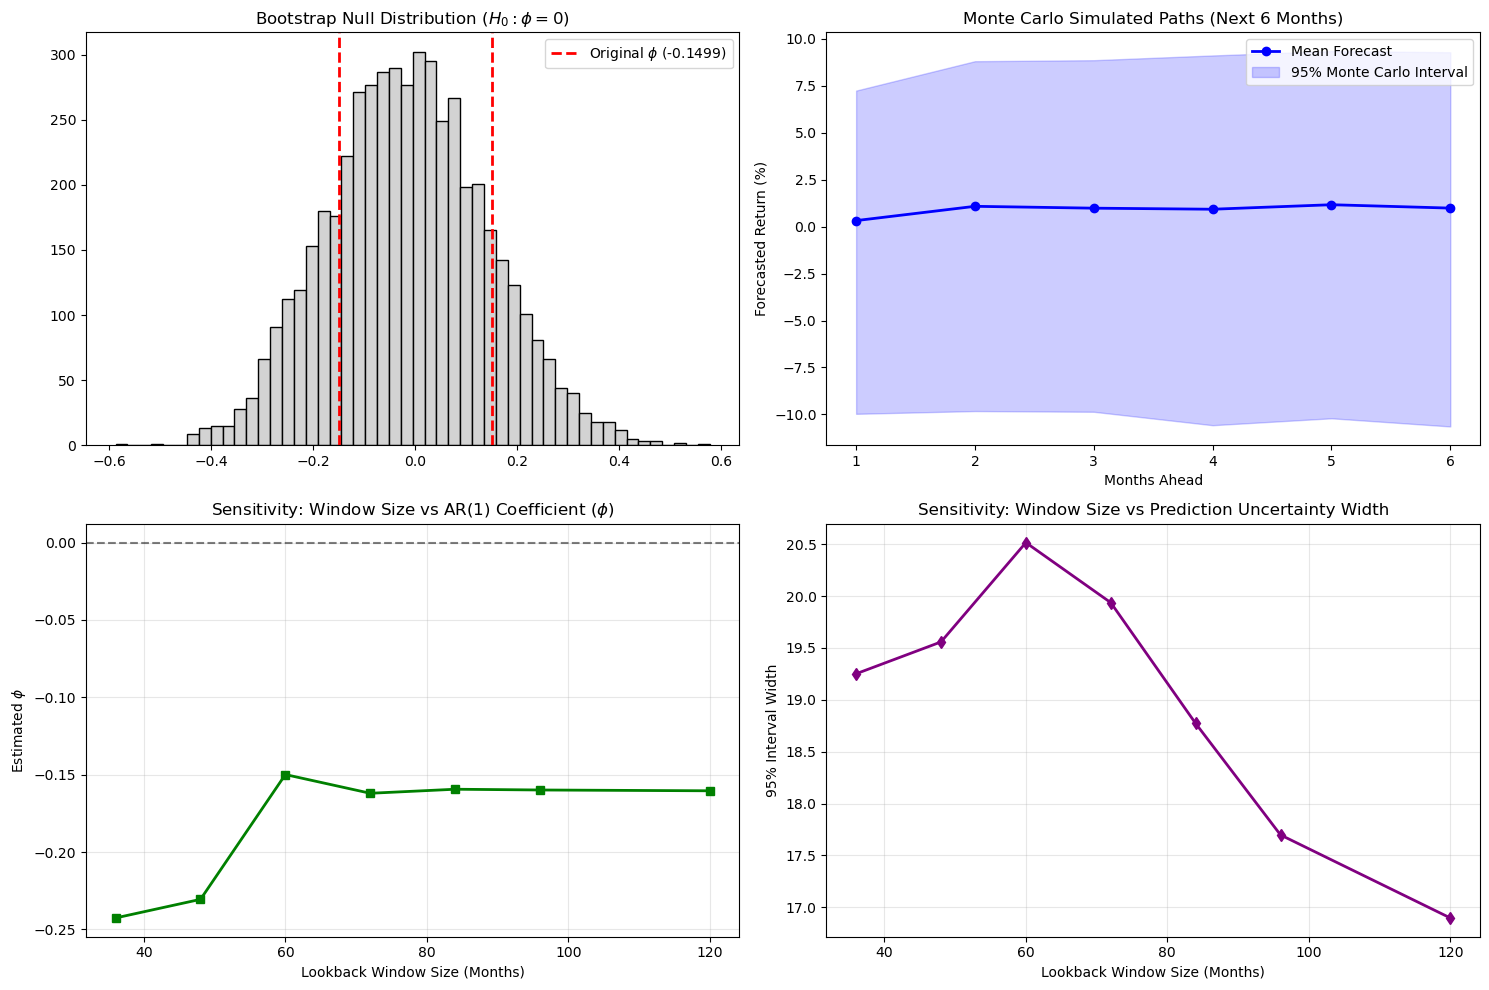

In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from arch import arch_model
import matplotlib.pyplot as plt
import yfinance as yf
import warnings

# 불필요한 경고 숨기기
warnings.filterwarnings('ignore')

# =====================================================================
# 0. 데이터 준비 (S&P 500 월간 수익률)
# =====================================================================
print("데이터를 다운로드하고 전처리합니다...")
ticker = "^GSPC"
df = yf.download(ticker, start="2010-01-01", end="2024-03-01", progress=False)

df = df.resample('ME').last()
df['Return'] = df['Close'].pct_change() * 100  # % 단위 스케일링
df = df.dropna()
y_full = df['Return']

# 베이스라인 윈도우 설정 (최근 60개월)
window_size = 60
y = y_full.iloc[-window_size:]
T = len(y)

# =====================================================================
# 1. 원본 데이터 모델 피팅 (AR(1) + GARCH(1,1))
# =====================================================================
X = sm.add_constant(y.shift(1).dropna())
model_ar = sm.OLS(y.iloc[1:], X).fit()
c_hat, phi_hat = model_ar.params.iloc[0], model_ar.params.iloc[1]

resids = model_ar.resid
garch = arch_model(resids, vol='Garch', p=1, q=1, rescale=False)
garch_fit = garch.fit(disp='off')

omega, alpha, beta = garch_fit.params['omega'], garch_fit.params['alpha[1]'], garch_fit.params['beta[1]']
cond_vol = garch_fit.conditional_volatility
std_resids = (resids / cond_vol).dropna().values

# =====================================================================
# 2. Strict 부트스트랩 가설검정 (Ruiz 2002 - Scheme iii 귀무가설 생성)
# =====================================================================
print("\n[진행중] 엄밀한 부트스트랩 가설검정 수행 중 (H0: Phi=0)...")
# 귀무가설(Phi=0) 하의 상수항 모델 피팅
model_h0 = sm.OLS(y, np.ones(T)).fit()
c_h0 = model_h0.params.iloc[0]
resids_h0 = model_h0.resid

# H0 잔차에 대한 GARCH 피팅
garch_h0 = arch_model(resids_h0, vol='Garch', p=1, q=1, rescale=False)
garch_fit_h0 = garch_h0.fit(disp='off')
omega_h0, alpha_h0, beta_h0 = garch_fit_h0.params['omega'], garch_fit_h0.params['alpha[1]'], garch_fit_h0.params['beta[1]']
std_resids_h0 = (resids_h0 / garch_fit_h0.conditional_volatility).dropna().values

iterations = 5000
boot_phis_null = []

for _ in range(iterations):
    sim_y = np.zeros(T)
    sim_sigma2 = np.zeros(T)
    sim_eps = np.zeros(T)
    
    sim_sigma2[0] = np.var(resids_h0)
    sim_eps[0] = resids_h0.iloc[0]
    sim_y[0] = y.iloc[0]
    
    random_z = np.random.choice(std_resids_h0, size=T, replace=True)
    
    # 귀무가설(Phi=0) 하에서 재귀적 데이터 생성
    for t in range(1, T):
        sim_sigma2[t] = omega_h0 + alpha_h0 * (sim_eps[t-1]**2) + beta_h0 * sim_sigma2[t-1]
        sim_eps[t] = np.sqrt(sim_sigma2[t]) * random_z[t]
        sim_y[t] = c_h0 + sim_eps[t] # Phi가 반영되지 않은 순수 노이즈 시계열
        
    # 생성된 가상 H0 시계열에 AR(1) 모델을 강제로 적합하여 나오는 가짜 Phi 추출
    sim_X = sm.add_constant(pd.Series(sim_y).shift(1).dropna())
    sim_model = sm.OLS(sim_y[1:], sim_X).fit()
    boot_phis_null.append(sim_model.params.iloc[1])

boot_phis_null = np.array(boot_phis_null)
# 부트스트랩 P-value: H0하에서 생성된 가짜 Phi들이 실제 추정된 원본 Phi보다 극단적으로 나올 확률
p_value = np.mean(np.abs(boot_phis_null) >= np.abs(phi_hat))

# =====================================================================
# 3. 몬테카를로 시뮬레이션 (향후 6개월 다중 경로 예측)
# =====================================================================
print("[진행중] 향후 6개월 몬테카를로 시뮬레이션 다중 경로 생성 중...")
H = 6 # 6개월 예측
mc_paths = np.zeros((iterations, H))

last_y = y.iloc[-1]
last_eps = resids.iloc[-1]
last_sigma2 = cond_vol.iloc[-1]**2

for i in range(iterations):
    curr_y, curr_eps, curr_sigma2 = last_y, last_eps, last_sigma2
    for h in range(H):
        z_star = np.random.choice(std_resids) # 무작위 충격
        next_sigma2 = omega + alpha * (curr_eps**2) + beta * curr_sigma2
        next_eps = np.sqrt(next_sigma2) * z_star
        next_y = c_hat + phi_hat * curr_y + next_eps
        
        mc_paths[i, h] = next_y
        curr_y, curr_eps, curr_sigma2 = next_y, next_eps, next_sigma2

mc_mean_path = np.mean(mc_paths, axis=0)
mc_lower_path = np.percentile(mc_paths, 2.5, axis=0)
mc_upper_path = np.percentile(mc_paths, 97.5, axis=0)

# =====================================================================
# 4. 하이퍼파라미터 민감도 분석 (Window Size 변경에 따른 Robustness)
# =====================================================================
print("[진행중] 하이퍼파라미터(Window Size) 민감도 분석 수행 중...")
window_sizes = [36, 48, 60, 72, 84, 96, 120]
sens_phi = []
sens_width = []

for w in window_sizes:
    y_sub = y_full.iloc[-w:]
    X_sub = sm.add_constant(y_sub.shift(1).dropna())
    model_sub = sm.OLS(y_sub.iloc[1:], X_sub).fit()
    sens_phi.append(model_sub.params.iloc[1])
    
    # 95% 예측 불확실성(구간 너비) 근사치: 표준오차 * 1.96 * 2
    sens_width.append(2 * 1.96 * np.std(model_sub.resid))

# =====================================================================
# 5. 결과 출력 및 시각화
# =====================================================================
print("\n" + "="*50)
print("🎯 [결과 1] AR(1) 계수 유의성 검정 (논문 Scheme iii 기준)")
print("="*50)
print(f"원본 추정 AR(1) 계수: {phi_hat:.4f}")
print(f"귀무가설(Phi=0) 하에서의 Bootstrap P-value: {p_value:.4f}")
if p_value < 0.05:
    print("=> 결론: P-value < 0.05 이므로 AR(1) 계수는 통계적으로 유의합니다.")
else:
    print("=> 결론: P-value >= 0.05 이므로 AR(1) 계수는 통계적으로 유의하지 않습니다.")

# 시각화 셋업
fig = plt.figure(figsize=(15, 10))

# Plot 1: 부트스트랩 P-value 분포
ax1 = plt.subplot(2, 2, 1)
ax1.hist(boot_phis_null, bins=50, color='lightgray', edgecolor='black')
ax1.axvline(phi_hat, color='red', linestyle='dashed', linewidth=2, label=f'Original $\phi$ ({phi_hat:.4f})')
ax1.axvline(-phi_hat, color='red', linestyle='dashed', linewidth=2)
ax1.set_title('Bootstrap Null Distribution ($H_0: \phi=0$)')
ax1.legend()

# Plot 2: 향후 6개월 몬테카를로 시뮬레이션 경로
ax2 = plt.subplot(2, 2, 2)
ax2.plot(range(1, H+1), mc_mean_path, color='blue', marker='o', linewidth=2, label='Mean Forecast')
ax2.fill_between(range(1, H+1), mc_lower_path, mc_upper_path, color='blue', alpha=0.2, label='95% Monte Carlo Interval')
ax2.set_title('Monte Carlo Simulated Paths (Next 6 Months)')
ax2.set_xlabel('Months Ahead')
ax2.set_ylabel('Forecasted Return (%)')
ax2.legend()

# Plot 3: 민감도 분석 - 윈도우 사이즈 vs Phi 계수
ax3 = plt.subplot(2, 2, 3)
ax3.plot(window_sizes, sens_phi, marker='s', color='green', linewidth=2)
ax3.axhline(0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('Sensitivity: Window Size vs AR(1) Coefficient ($\phi$)')
ax3.set_xlabel('Lookback Window Size (Months)')
ax3.set_ylabel('Estimated $\phi$')
ax3.grid(True, alpha=0.3)

# Plot 4: 민감도 분석 - 윈도우 사이즈 vs 모델 불확실성
ax4 = plt.subplot(2, 2, 4)
ax4.plot(window_sizes, sens_width, marker='d', color='purple', linewidth=2)
ax4.set_title('Sensitivity: Window Size vs Prediction Uncertainty Width')
ax4.set_xlabel('Lookback Window Size (Months)')
ax4.set_ylabel('95% Interval Width')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Heteroscedasticity and Autocorrelation-Consistent Estimation of the Standard Error

In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import yfinance as yf
import pandas_datareader.data as web
ff_data=web.DataReader('F-F_Research_Data_Factors', 'famafrench', start='2015-01-01', end='2024-01-01')
ff3=ff_data[0] 
spy=yf.download("SPY", start="2015-01-01", end="2024-01-01", progress=False)['Close']
spy_returns=spy.resample('ME').last().pct_change().dropna() * 100
spy_returns.index=spy_returns.index.to_period('M')
data=pd.concat([spy_returns, ff3], axis=1).dropna()
data.columns=['SPY', 'Mkt-RF', 'SMB', 'HML', 'RF']
y=data['SPY']-data['RF']
x=data[['Mkt-RF', 'SMB', 'HML']]
x=sm.add_constant(x)
model=sm.OLS(y, x)
results_standard=model.fit()
results_hac=model.fit(cov_type='HAC', cov_kwds={'maxlags': 6})

comparison_df = pd.DataFrame({
    '일반 OLS 표준오차': results_standard.bse,
    'HAC 표준오차': results_hac.bse,
    '일반 P-value': results_standard.pvalues,
    'HAC P-value': results_hac.pvalues
})
print(comparison_df.round(4))

        일반 OLS 표준오차  HAC 표준오차  일반 P-value  HAC P-value
const        0.0288    0.0266      0.7915       0.7740
Mkt-RF       0.0062    0.0077      0.0000       0.0000
SMB          0.0108    0.0123      0.0000       0.0000
HML          0.0073    0.0089      0.0939       0.1652
